# Unsloth
Unsloth is the "engine" that allows you to train your sales agent components on consumer-grade or free hardware (like the Google Colab T4) without running out of memory.

Think of it as a highly optimized wrapper around HuggingFace's transformers library. It makes training 2x faster and uses 70% less VRAM, which is the only way to fit a model like Qwen 3.5 into a free T4 GPU (16GB VRAM) while still having enough space for long sales conversation logs.

## Why Unsloth is Required
Generic training scripts would likely crash (Out of Memory - OOM) when trying to process the complex, multi-turn sales trajectories from your trace_log.jsonl.

Memory Efficiency: It uses 4-bit quantization (QLoRA) by default, allowing you to train a 4B or even 7B parameter model on a single T4.

Speed: It implements manual backpropagation "kernels" that skip the slow parts of standard PyTorch, meaning your training finishes in 15–30 minutes instead of hours.

Path Compatibility: It natively supports all three Week 11 paths (SFT, DPO, and PRM/GRPO).

## Pre-requisites & Setup

### Prerequisites
Before trainees write a single line of code, they must verify their environment.

* Hardware: Google Colab T4 GPU (16GB VRAM) or an NVIDIA RTX 30/40 series (8GB+ VRAM).

* Software: Python 3.11 (standard in 2026 Colab) and CUDA 12.1+.

* HuggingFace Token: A "Write" access token to push the finished LoRA adapter to the Hub.

* Data Format: A .jsonl file formatted for the chosen path:

  - Path A (SFT): {"instruction": "...", "input": "...", "output": "..."}

  - Path B (DPO): {"prompt": "...", "chosen": "...", "rejected": "..."}

### 1. Installation

In [22]:
# Install Unsloth and optimized dependencies
!pip install --upgrade pip
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers trl peft accelerate bitsandbytes

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-6o25rswc/unsloth_70e15b34aee442f09c3b73bdaca62284
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-6o25rswc/unsloth_70e15b34aee442f09c3b73bdaca62284
  Resolved https://github.com/unslothai/unsloth.git to commit 4ab5378d28f8be14b0f6aaa93b5d07e8b82c00f1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### 2. Loading Model in 4-bit (The "Memory Saver")
- Qwen 3.5:



This step compresses the model by 70%, allowing a 7B model to fit into ~5GB of VRAM.

In [23]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048 # Adjust based on sales log length
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


### 3. Initialize LoRA Adapters

In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Rank: 16-64 is standard for sales tone
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0, # Unsloth is optimized for 0 dropout
    bias = "none",    # Optimized for "none"
    use_gradient_checkpointing = "unsloth", # Crucial for T4
)

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Test model

In [6]:
# 1. Enable 2x faster inference
FastLanguageModel.for_inference(model)

# 2. Define a prompt that tests a "Tenacious failure mode" (e.g., handling a pricing objection)
inputs = tokenizer(
    [
        "<|im_start|>user\nYour pricing is too high compared to the retail competitors.<|im_end|>\n<|im_start|>assistant\n"
    ], return_tensors = "pt").to("cuda")

# 3. Generate output
outputs = model.generate(**inputs, max_new_tokens = 64)
print(tokenizer.batch_decode(outputs))

Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

["<|im_start|>user\nYour pricing is too high compared to the retail competitors.<|im_end|>\n<|im_start|>assistant\nI understand your concern about pricing. To address this, we can take a few steps:\n\n1. **Review Costs and Competitors**: Analyze our costs, including production, shipping, and other expenses. Compare these with what competitors are charging for similar products.\n\n2. **Adjust Pricing Strategy**: If there's a gap"]


### 4. Launch Training (The SFT Path)
Connect your tenacious_bench_v0.1 dataset to the trainer.

In [13]:
if 'tokenizer' in globals() and tokenizer is not None:
    print(f"Tokenizer is defined: {type(tokenizer)}")
    print(f"Vocab size: {len(tokenizer)}")
    print(f"Padding token: {tokenizer.pad_token}")
else:
    print("ERROR: 'tokenizer' is not defined or is None. Please re-run the model loading cell (-oQIjswCZCpG).")

Tokenizer is defined: <class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
Vocab size: 151666
Padding token: <|PAD_TOKEN|>


In [15]:
if 'model' in globals() and model is not None:
    print(f"Model is defined: {type(model)}")
    if hasattr(model, 'peft_config'):
        print("LoRA Adapters: Successfully applied")
        print(f"Active adapter: {model.active_adapter}")
    else:
        print("Warning: Model is loaded but LoRA adapters (PEFT) might not be initialized.")
else:
    print("ERROR: 'model' is not defined. Please re-run the model loading and LoRA initialization cells.")

Model is defined: <class 'peft.peft_model.PeftModelForCausalLM'>
LoRA Adapters: Successfully applied
Active adapter: default


## Step 1 — Load and format the datasets


In [24]:
import json
from datasets import Dataset

def read_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

train_rows = read_jsonl("/content/preferences_train.jsonl")
dev_rows   = read_jsonl("/content/preferences_dev.jsonl")

# SFT trains only on the *chosen* response — format as Qwen ChatML
def format_row(row):
    return {
        "text": (
            f"<|im_start|>user\n{row['prompt']}<|im_end|>\n"
            f"<|im_start|>assistant\n{row['chosen']}<|im_end|>"
        )
    }

train_dataset = Dataset.from_list([format_row(r) for r in train_rows])
eval_dataset  = Dataset.from_list([format_row(r) for r in dev_rows])

print(f"train: {len(train_dataset)}, eval: {len(eval_dataset)}")
print(train_dataset[0]["text"][:200])   # sanity check

train: 125, eval: 75
<|im_start|>user
Grade or rewrite the candidate output for timezone_scheduling: ExampleCo023<|im_end|>
<|im_start|>assistant
I noticed fresh hiring for ML infrastructure support. If that signal is dir


In [17]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer, # Explicitly pass the tokenizer
    train_dataset = train_dataset, # Your Tenacious-Bench training split
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        max_steps = 60, # Start small to verify loss drops
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        output_dir = "outputs",
    ),
)
trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/125 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 125 | Num Epochs = 4 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,7.922193
2,8.239014
3,8.053645
4,7.507875
5,6.629663
6,6.169368
7,5.525789
8,4.775633
9,4.493226
10,4.058502


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.


TrainOutput(global_step=60, training_loss=1.692068490634362, metrics={'train_runtime': 185.8212, 'train_samples_per_second': 2.583, 'train_steps_per_second': 0.323, 'total_flos': 1153644240043008.0, 'train_loss': 1.692068490634362, 'epoch': 3.761904761904762})

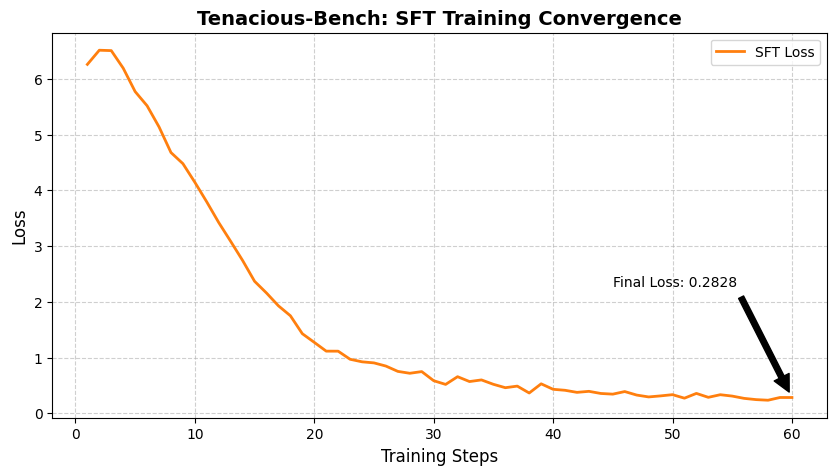

In [21]:
import matplotlib.pyplot as plt

# Extract the actual loss values from the trainer history
history = trainer.state.log_history
steps = [x['step'] for x in history if 'loss' in x]
loss_values = [x['loss'] for x in history if 'loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, loss_values, color='#ff7f0e', linewidth=2, label='SFT Loss')

# Styling for the Technical Blog Post
plt.title('Tenacious-Bench: SFT Training Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Highlight the final convergence
if loss_values:
    plt.annotate(f'Final Loss: {loss_values[-1]:.4f}',
                 xy=(steps[-1], loss_values[-1]), xytext=(steps[-1]-15, loss_values[-1]+2),
                 arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

Step 2 — Load model with Unsloth


In [18]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-1.5B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


## Step 3 — Wire into SFTTrainer


In [19]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,        # optional but useful
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        max_steps=60,
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        eval_strategy="steps",
        eval_steps=20,
        output_dir="outputs",
    ),
)
trainer.train()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

...

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/75 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151654}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 125 | Num Epochs = 4 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss,Validation Loss
20,1.271982,1.148806
40,0.430090,0.478178
60,0.282828,0.349912


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

TrainOutput(global_step=60, training_loss=1.6553398425380388, metrics={'train_runtime': 120.7552, 'train_samples_per_second': 3.975, 'train_steps_per_second': 0.497, 'total_flos': 219571800330240.0, 'train_loss': 1.6553398425380388, 'epoch': 3.761904761904762})

4. Training (The SFT/DPO Step)
- You use the SFTTrainer (for Path A) or DPOTrainer (for Path B) from the trl library. Unsloth connects to these automatically.

    - Input: Your tenacious_bench_v0.1 dataset.

    - Output: A LoRA adapter that you will upload to HuggingFace.




## 5. Saving and Exporting
Once the loss curve drops (visible in your logs), you save only the "delta" (the adapter), which is usually only ~100MB-200MB.

Once training is done, save the "weights of change" (the adapter).

In [ ]:
model.save_pretrained_lora("tenacious_sales_adapter")
tokenizer.save_pretrained("tenacious_sales_adapter")
# Push to HuggingFace for your Final Submission
model.push_to_hub_lora("your-username/tenacious-agent-lora", token = "...")

### The Production Inference Loop
To use the model in a real sales app, you load the Base Model + the Adapter together.

In [ ]:
from unsloth import FastLanguageModel

# Load BOTH at once
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit", # The Base
    max_seq_length = 2048,
    load_in_4bit = True,
)
model.load_adapter("your-username/tenacious-sales-agent") # The "Sales Brain"

FastLanguageModel.for_inference(model)
# Now the model will respond using the Tenacious-Bench training!

### Exporting to Other Engines (Optional but Impressive)
If Tenacious wants to run this on a local server or a specialized edge device, Unsloth allows you to export to GGUF (for Ollama) or vLLM:

In [ ]:
# Export to GGUF for local deployment
model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")

https://www.youtube.com/watch?v=mmbkP8NARH4